In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [2]:
reviews = pd.read_csv(RAW_DIR / "olist_order_reviews_dataset.csv")

In [3]:
print(f"Dataset: {reviews.shape}")

Dataset: (99224, 7)


In [4]:
# 1. Tổng quan
print("\n=== TỔNG QUAN ===")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nĐiểm TB: {reviews['review_score'].mean():.2f}")
print(f"Tỉ lệ thiếu comment: {reviews['review_comment_message'].isna().mean()*100:.1f}%")


=== TỔNG QUAN ===
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Điểm TB: 4.09
Tỉ lệ thiếu comment: 58.7%


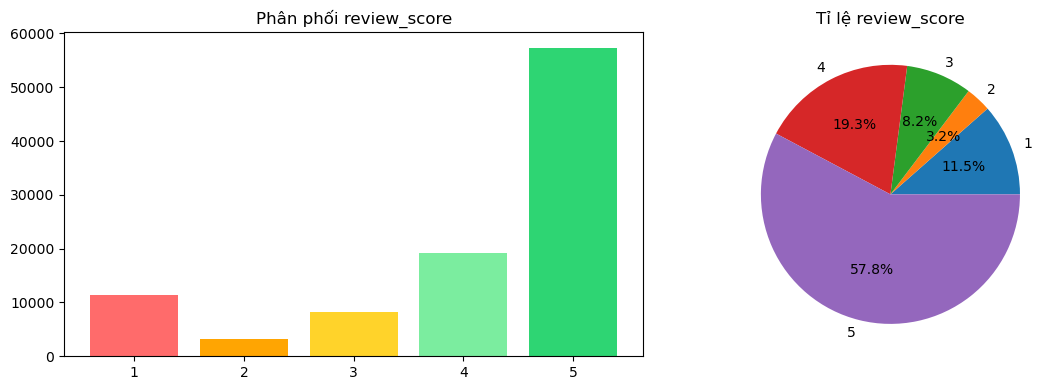

In [5]:
# 2. Phân phối điểm
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
score_counts = reviews['review_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color=['#ff6b6b','#ffa502','#ffd32a','#7bed9f','#2ed573'])
axes[0].set_title('Phân phối review_score')
axes[1].pie(score_counts.values, labels=score_counts.index, autopct='%1.1f%%')
axes[1].set_title('Tỉ lệ review_score')
plt.tight_layout()
plt.show()

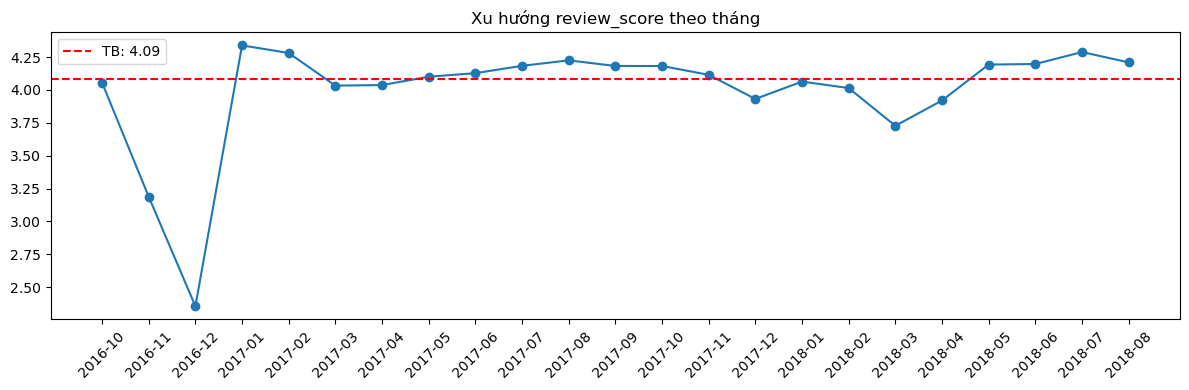

In [6]:
# 3. Xu hướng theo thời gian
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['year_month'] = reviews['review_creation_date'].dt.to_period('M')
monthly_score = reviews.groupby('year_month')['review_score'].mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_score.index.astype(str), monthly_score.values, marker='o')
plt.axhline(y=reviews['review_score'].mean(), color='r', linestyle='--', label=f'TB: {reviews["review_score"].mean():.2f}')
plt.title('Xu hướng review_score theo tháng')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# 4. Thời gian phản hồi
reviews['answer_days'] = (pd.to_datetime(reviews['review_answer_timestamp']) - reviews['review_creation_date']).dt.days
print(f"\n=== THỜI GIAN PHẢN HỒI ===")
print(f"Trung bình: {reviews['answer_days'].mean():.1f} ngày")
print(f"Trung vị: {reviews['answer_days'].median():.1f} ngày")



=== THỜI GIAN PHẢN HỒI ===
Trung bình: 2.6 ngày
Trung vị: 1.0 ngày


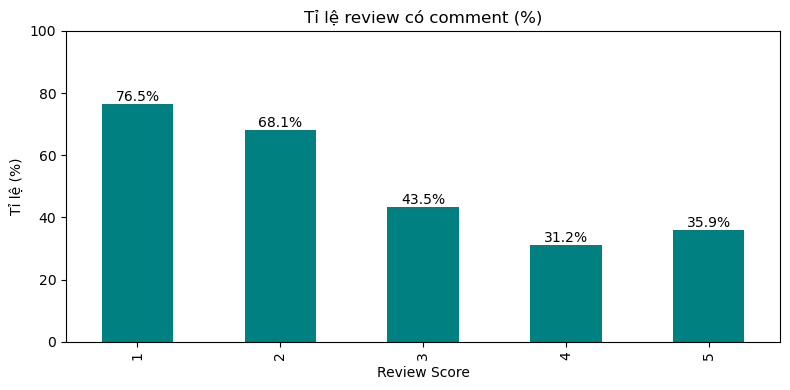

In [8]:
# 5. Tỉ lệ có comment theo điểm
has_comment = reviews.groupby('review_score')['review_comment_message'].apply(lambda x: (1 - x.isna().mean())*100)

plt.figure(figsize=(8, 4))
has_comment.plot(kind='bar', color='teal')
plt.title('Tỉ lệ review có comment (%)')
plt.xlabel('Review Score')
plt.ylabel('Tỉ lệ (%)')
plt.ylim(0, 100)
for i, v in enumerate(has_comment):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

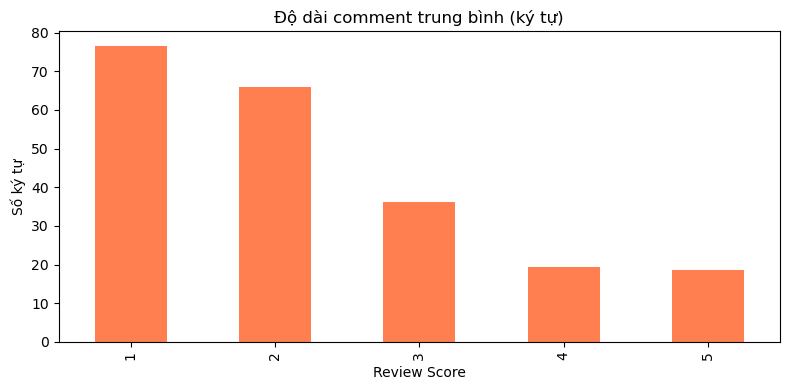

In [9]:
# 6. Độ dài comment
reviews['comment_len'] = reviews['review_comment_message'].fillna('').apply(len)
len_by_score = reviews.groupby('review_score')['comment_len'].mean()

plt.figure(figsize=(8, 4))
len_by_score.plot(kind='bar', color='coral')
plt.title('Độ dài comment trung bình (ký tự)')
plt.xlabel('Review Score')
plt.ylabel('Số ký tự')
plt.tight_layout()
plt.show()


In [10]:
# 7. Mối quan hệ
print("\n=== TƯƠNG QUAN ===")
corr = reviews[['review_score', 'answer_days', 'comment_len']].corr()
print(corr.round(3))



=== TƯƠNG QUAN ===
              review_score  answer_days  comment_len
review_score         1.000        0.006       -0.388
answer_days          0.006        1.000       -0.003
comment_len         -0.388       -0.003        1.000


In [11]:
# 8. Kết luận chính
print("\n=== KẾT LUẬN ===")
print(f"✓ Điểm trung bình: {reviews['review_score'].mean():.2f}/5.0")
print(f"✓ Tỉ lệ đánh giá tốt (4-5 sao): {(reviews['review_score'] >= 4).mean()*100:.1f}%")
print(f"✓ Tỉ lệ đánh giá tệ (1-2 sao): {(reviews['review_score'] <= 2).mean()*100:.1f}%")
print(f"✓ Thời gian phản hồi trung bình: {reviews['answer_days'].mean():.1f} ngày")
print(f"✓ Review càng thấp càng có xu hướng viết comment dài và được phản hồi nhanh hơn")


=== KẾT LUẬN ===
✓ Điểm trung bình: 4.09/5.0
✓ Tỉ lệ đánh giá tốt (4-5 sao): 77.1%
✓ Tỉ lệ đánh giá tệ (1-2 sao): 14.7%
✓ Thời gian phản hồi trung bình: 2.6 ngày
✓ Review càng thấp càng có xu hướng viết comment dài và được phản hồi nhanh hơn
